# Toy Example of S-phase Copy Number Replication Normalization

May 24, 2024

## Goal:
Create a procedure to make clear the copy number correction process

## Inputs:
- Raw gene expression reads
- Replication timing profile (deconvolved time, more granular than the experiment)
- H matrix with information on how much of each cell has progressed through the cell cycle.



In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


(79, 50)

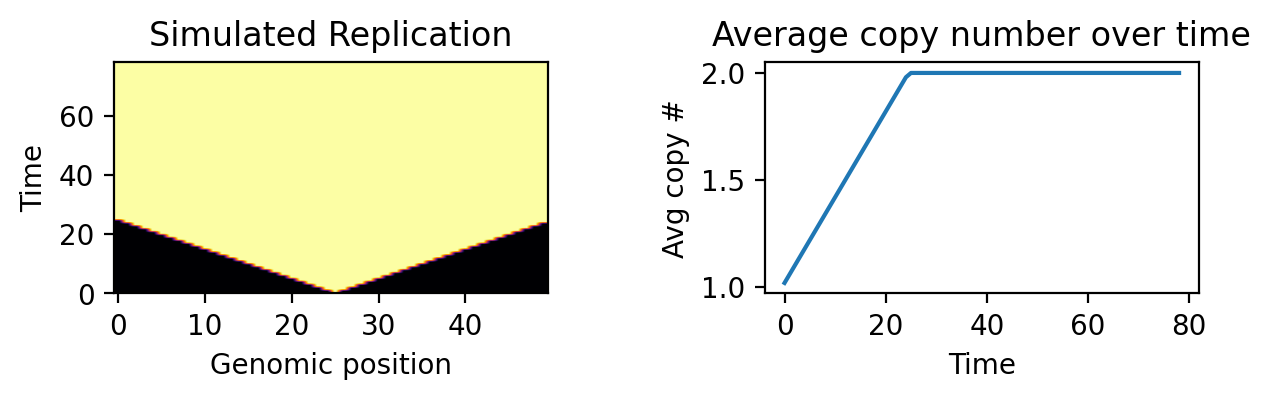

In [32]:
from src.ToyReplication import ToyReplication

# Let's create a replication profile with the dimensions of H
from src.delta_config import load_yl_delta_config
from src.helpers import calcH

length_timecourse = 100
step_min = 10 # Progress time by 10 minutes

config = load_yl_delta_config(1)
tps = np.arange(0, length_timecourse, step_min)
H, hpos = calcH(config.intervals_wt1, tps)

# Select the postG1 indices and create a repliation profile
# with these columns in mind
postG1_indices = config.get_Hpositions_for_phase('postG1')

# So the replication profile will have 79 timepoints
deconv_tps = np.arange(len(postG1_indices))

n = 50 # 100, 10 kb windows
origins = {
    0:[25],
}

# Replication profile 
toy_repl_example = ToyReplication(n=n, timepoints=deconv_tps, origins=origins)
toy_repl_example.replicate()
toy_repl_example.plot_replication()

# Replication timing matrix that indicates where in H (postG1's indices)
# replication occurs
toy_repl_example.replication_matrix.shape

In [35]:
observed_reads = np.zeros((n, len(tps))) + 100.
observed_reads.shape

(50, 10)

In [107]:
from src.CopyNumberCorrection import copy_number_correct_H_index
from src.helpers import summarize_columns_by_indices

H_index_rep_profile = toy_repl_example.replication_matrix
replication_indices = H_index_rep_profile.argmax(axis=0) + postG1_indices[0]

last_indices = np.repeat(H.shape[1]-1, len(replication_indices))

prop_copy2 = np.zeros((len(replication_indices), len(tps)))

repl_spans = list(zip(replication_indices, last_indices))
for i in range(len(repl_spans)):
    start, end = repl_spans[i]
    prop_copy2[i] = H[:, start:end].sum(axis=1)


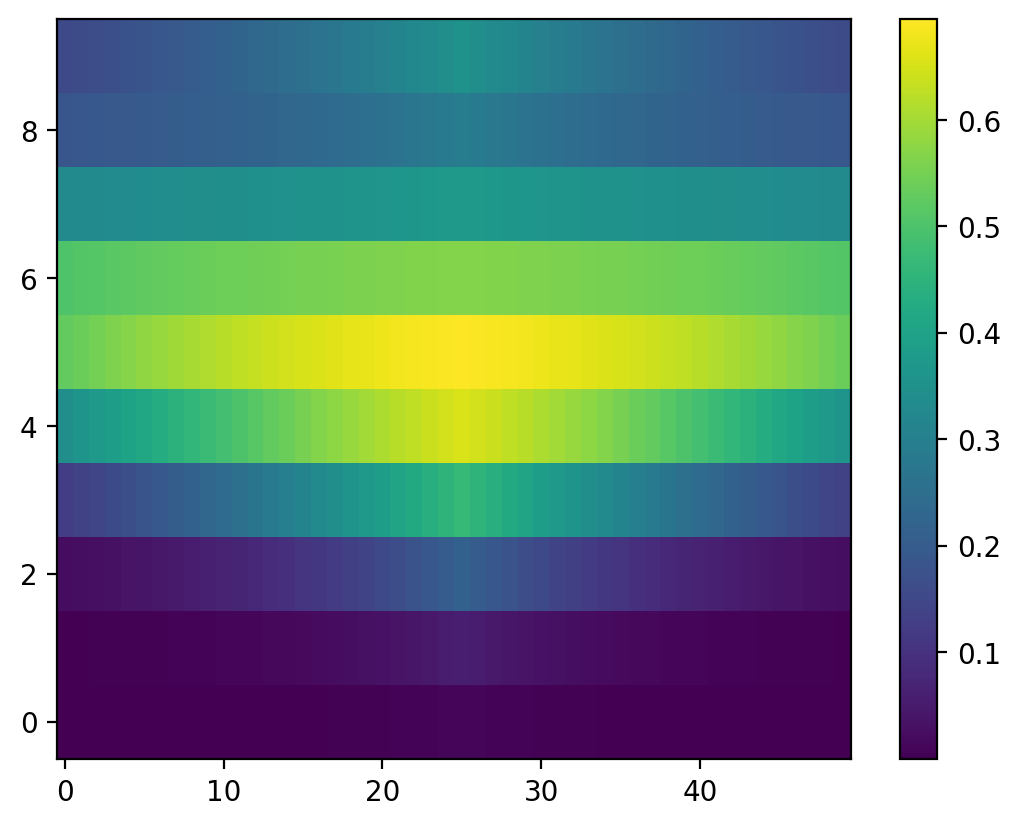

In [117]:
plt.imshow(prop_copy2.T, origin='lower', aspect='auto')
plt.colorbar()